In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve

import plotly.graph_objects as go

from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
API_KEY = "Nc1dTFzE1dg6gchvs0voTKE07XuuXIKW"


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

c:\Users\lhager\AppData\Local\Programs\Python\Python311\xrd_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path_1050 = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Si\Data\Stückchen\XRD\ESPIN\W1_9_3_1050C_2min_in-plane_GIXRD_detector_scan.xy"
data_1050 = pd.read_csv(file_path_1050, delimiter="\t", skiprows=2, header=0, names=['Angle', 'Intensity'])

file_path_700 = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Si\Data\Stückchen\XRD\ESPIN\W1_12_5_700C_120s_in-plane_GIXRD_detector_scan.xy"
data_700 = pd.read_csv(file_path_700, delimiter="\t", skiprows=2, header=0, names=['Angle', 'Intensity'])

file_path_800 = r"../Data/XRD/02202026_Ni2Si_800grad_.xy"
data_800 = pd.read_csv(file_path_800, delimiter=" ", skiprows=1, header=None, names=['Angle', 'Intensity'])

file_path_900 = r"../Data/XRD/02182026_Ni2Si_900grad_.xy"
data_900 = pd.read_csv(file_path_900, delimiter=" ", skiprows=1, header=None, names=['Angle', 'Intensity'])

In [3]:
from processXRD import process_XRD_data
processed_data_900, peak_angles_900 = process_XRD_data(data_900, roi=False)
processed_data_800, peak_angles_800 = process_XRD_data(data_800, roi=True, roi_start=64.5, roi_end=66.5)

processed_data_700, peak_angles_700 = process_XRD_data(data_700, roi=False, baseline_params={'lam': 1e7, 'p': 0.0001, 'niter': 10})

processed_data_1050, peak_angles_1050 = process_XRD_data(data_1050, roi=False, baseline_params={'lam': 1e7, 'p': 0.0001, 'niter': 10})

k:\tech_stud\Hager_Lutz\VS_Code\Master_data\XRD\processXRD.py:17: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


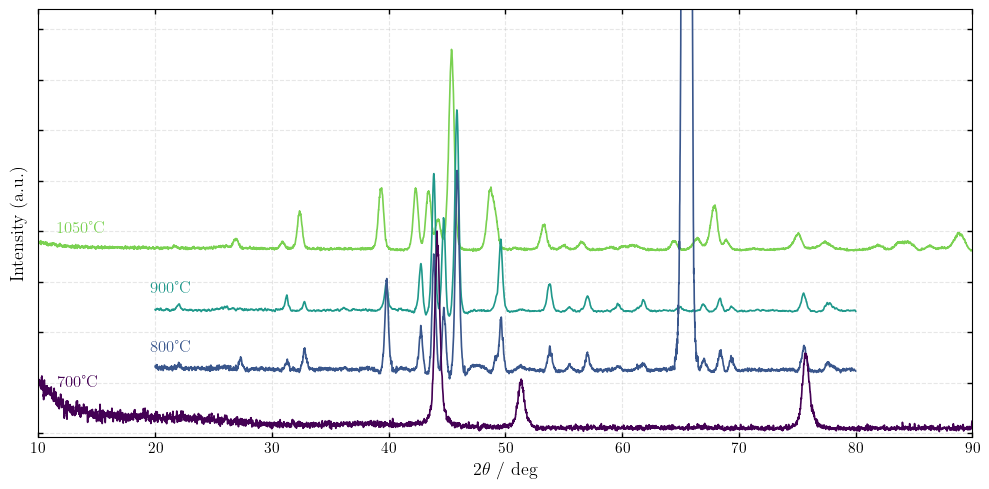

In [ ]:
colors = plt.get_cmap('viridis_r')(np.linspace(0.2, 1, 4))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(processed_data_1050['Angle'], processed_data_1050['intensity_norm']+0.9, color=colors[0], lw=1.2, zorder=2) 
ax.plot(processed_data_900['Angle'], processed_data_900['intensity_norm']+0.6, color=colors[1], lw=1.2, zorder=2) 
ax.plot(processed_data_800['Angle'], processed_data_800['intensity_norm']+0.3, color=colors[2], lw=1.2, zorder=2) 
ax.plot(processed_data_700['Angle'], processed_data_700['intensity_norm'], color=colors[3], lw=1.2, zorder=2) 

ax.tick_params(axis='both', which='both', direction='in', 
                top=True, right=True, 
                width=1.0, labelsize=11)
ax.set_yticklabels([])
ax.set_xlim(10, 90)
ax.set_ylim(-0.02, 2.1)

ax.set_xlabel(r"$2\theta$ / deg", fontsize=13)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=13)

ax.text(0.02, 0.48, '1050°C', transform=ax.transAxes, fontsize=12, color=colors[0])
ax.text(0.12, 0.34, '900°C', transform=ax.transAxes, fontsize=12, color=colors[1])
ax.text(0.12, 0.20, '800°C', transform=ax.transAxes, fontsize=12, color=colors[2])
ax.text(0.02, 0.12, '700°C', transform=ax.transAxes, fontsize=12, color=colors[3])

ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
# ax.legend(frameon=True, edgecolor='black', fancybox=False, fontsize=10, loc='upper right')

plt.tight_layout()
# plt.savefig(f'../Images/XRD/Ni_2Si_combined.pdf', dpi=500)
# plt.savefig(os.path.join(os.path.dirname(file_path_700), 'Ni_2Si_combined.pdf'), dpi=300)
plt.show()

In [ ]:
final_peaks = {
'$Ni_2Si$': [27.32, 32.8, 39.82, 42.78, 43.92, 45.86, 53.86], # 43.92
'$NiSi$': [31.28, 49.58, 61.78, 66.98, 75.54], 
'$Ni_3Si_2$': [44.74, 77.58],
'$Ni_{31}Si_{12}$': [57.04, 68.44]
# 'Ni': [44.5]   # 77.62
}